# 22 — Four-Class Taxonomy: Splitting Approached-NC with Gaze Regression

Notebook 21 showed 3-class separation (clicked / approached-NC / not-approached) with
approached-NC as the best-separated class (F1 0.720, recall 81%). But "approached-NC"
conflates two populations:

- **Deferred** — user approached, retreated, then the **gaze** regressed back to the result band
- **Evaluated-rejected** — user approached, retreated, and the gaze never returned to that band

This notebook adds per-result **gaze regression** as a feature and tests 4-class separation.

> ⚠️ **`[LAB]`-only feature, despite the legacy name.** The "regression" detected here is a **gaze-fixation** sequence revisiting earlier result positions — not a scroll event. The detector below reads `fix['y']`, not the scroll stream. The variable is called `regression_labels` in code for historical neutrality, but prose should call it `gaze_regression_label`. **The four-class taxonomy is not computable without an eye tracker;** a scroll-only proxy is named future work for deploying this classification outside the lab.

**Depends on:** cursor-approach-features.json (notebook 15), data_loader (regression computation, reads `fix['y']`).

**Output for:** model-analysis.md §4.3, §6 (Missing: 4th class split), CIKM 2026 paper §5.

## Key Claims (authoritative for paper writers)

*Last verified against executed notebook output: 2026-04-12 (legacy K1–K12); bbox cascade values 2026-05-01.*
*Notebook: `22_four_class_taxonomy.ipynb`.*

If prose in a paper draft cites a value that disagrees with a row below, the paper is wrong — not the notebook. If re-running this notebook produces different values, update this block immediately and `grep` for the old value across `docs/`.

### 2026-05-01 attribution shift — bbox primary for AR replay rebuild

Per-AOI four-class label distribution recomputed under **bbox attribution**. **99.4% of trials (2,757/2,775) have at least one shifted four-class label** when switching from absolute to organic attribution. This affects the AR replay rebuild + curation captions, which were produced under the absolute-rank labels. M5 classifier was **NOT retrained** for this iteration — only the per-AOI labels shift.

### Bbox-attribution K-IDs (RECOMMENDED for paper figures + AR replay regeneration)

Source: `scripts/output/aoi-consumer-cascade/nb22_comparison.md` (n=2,775 trials).

#### Per-AOI class distribution

| ID | Class | Absolute count | Absolute share | Organic-bbox count | Organic-bbox share | Δ share |
|---|---|---|---|---|---|---|
| **K-bbox-1** | clicked | 2,763 | 8.2% | **2,362** | **8.9%** | +0.7 |
| **K-bbox-2** | deferred | 8,853 | 26.2% | **7,214** | **27.1%** | +0.9 |
| **K-bbox-3** | evaluated_rejected | 5,254 | 15.5% | **5,341** | **20.1%** | **+4.6** |
| **K-bbox-4** | not_approached | 16,919 | 50.1% | **11,664** | **43.9%** | **−6.2** |
| | **TOTAL AOIs** | **33,789** | 100% | **26,581** | 100% | |

The `evaluated_rejected` class grows substantially under bbox because ad-slot positions that were "not_approached" under absolute simply don't exist as positions under organic — the visited-but-not-clicked fraction shifts up. Total AOI count drops because ads/widgets are no longer counted as positions.

#### Per-trial averages

| ID | Claim | Absolute | Organic-bbox | Note |
|---|---|---|---|---|
| **K-bbox-5** | Mean visited positions / trial | 6.03 | **5.32** | bbox tighter — ad/widget visits not counted |
| **K-bbox-6** | Mean regressed positions / trial | 3.86 | **3.15** | |
| **K-bbox-7** | % of visited that are regressed | 64.0% | **59.3%** | |

#### Per-trial label stability

| ID | Claim | Value |
|---|---|---|
| **K-bbox-8** | Trials with any label-distribution change | **2,757 / 2,775 = 99.4%** |
| **K-bbox-9** | Trials where `clicked` count differs (click hit ad/widget under absolute, organic under bbox, or vice versa) | **411** |
| **K-bbox-10** | Trials where `deferred` count differs (regression detection picked up different positions) | **2,047** |

> **AOI cascade affects nearly every trial's class distribution.** AR replay rebuild + curation caption edits are gated on this: nearly every curated example in `approach-retreat/site/replay/data/curation.json` may have stale labels, and the 411 click-shift trials are particularly load-bearing because curation.json filters trials by class profile. Re-running `build_replay_trial.py` on those trials will produce fresh AOI labels via M5; caption claims like "5 DEFERRED AOIs" need automated cross-check before re-publishing demos.
>
> **M5 classifier not retrained.** The shift is in *labels*, not *predictions*. Retraining M5 on bbox AOIs is the next iteration.

---

### Legacy K-IDs (preserved for cross-reference)

The K1–K12 below are the published values verified 2026-04-12. Keep for paper-draft cross-references; new figures should cite K-bbox-* above.

### Regression-based four-class taxonomy

NB22 defines the four classes via cursor approach (min_dist < 100 px) + **gaze regression** to that position (the gaze-fixation sequence revisiting an earlier result band, detected from `fix['y']`, not scroll events), not via the classifier threshold used in NB21. **This makes the four-class taxonomy `[LAB]`-only by construction** — the variable is `regression_labels` in code for historical neutrality, but prose should call it `gaze_regression_label`. A scroll-only proxy is named future work. Class definitions are complementary to NB21, not competing.

| ID | Class | N | % |
|---|---|---|---|
| **K1** | Clicked | **2,228** | **16.6 %** |
| **K2** | Deferred (approached + regressed to) | **1,916** | **14.3 %** |
| **K3** | Evaluated-rejected (approached + no regression) | **439** | **3.3 %** |
| **K4** | Not approached | **8,836** | **65.8 %** |

### Motor signature separation (deferred vs evaluated-rejected)

| ID | Metric | Deferred | Eval-Rejected | *p* |
|---|---|---|---|---|
| **K5** | **Post-closest-approach drift** (px)¹ | **234.5** | **90.8** | **1.76 × 10⁻³⁸** |
| **K6** | Total gaze dwell (ms) | **4,137** | **1,612** | **9.76 × 10⁻⁷⁰** |
| **K7** | Dwell in proximity (ms) | **1,212.5** | **690.0** | **1.36 × 10⁻¹⁶** |

> ¹ **K5 is `distances[-1] − distances[min_dist_idx]`** in `notebooks-v2/15_cursor_approach.ipynb:325`. It measures **how far the cursor had drifted from its closest-approach point by the time the episode ended** — *not* max excursion, *not* arc length, *not* net Euclidean distance from the AOI. **Deferred has the larger K5 value (234 vs 91 px)** because deferred users park the cursor while fixating other candidates before regressing; eval-rejected users actively move the cursor to the next target, so post-closest drift stays small. This is the *opposite* direction from the "curved-close vs straight-far" intuition in earlier `approach-retreat/docs/theory.md` framings — the corrected interpretation is "deferred = cursor parked, eyes wandering; eval-rejected = cursor moving on with the eyes." The dissociation is real and strong; only the geometric metaphor needed updating.

### Click prediction with element-type interactions

| ID | Element type | N | Click% | M3 AUC | M3ei AUC | Δ |
|---|---|---|---|---|---|---|
| **K8** | organic | **10,379** | **17.6 %** | **0.857** | **0.859** | **+0.002** |
| **K9** | dd_top | **1,394** | **17.6 %** | **0.909** | **0.919** | **+0.010** |
| **K10** | native_ad | **1,646** | **9.2 %** | **0.830** | **0.817** | **−0.014** |

| ID | Model | LOSO AUC |
|---|---|---|
| **K11** | M3 (replication of NB21) | **0.859 ± 0.044** |
| **K12** | M3 + regression feature | **0.863 ± 0.042** (regression adds +0.003) |

> **Interaction features still help most on top ads.** Top ads gain +0.010 AUC from element-type interactions. Native ads lose −0.014 (avoidance behavior muddies the signal). Regression features add +0.003 to M3 — essentially zero; the forward-pass approach features carry the full signal.
>
> **Coordinate-space audit (2026-04-12, fixation side).** NB22 consumes `cursor-approach-features.json`, which was regenerated after the FPOGY page-space fix. The four-class split **strengthened dramatically**:
> - K2 deferred: 1,178 → **1,916** (+62.6%) — half the pre-fix "not approached" records were actually approached + regressed trials mislabeled by the scroll leak
> - K3 evaluated-rejected: 278 → **439** (+57.9%)
> - K4 not approached: 11,727 → **8,836** (−24.7%)
> - K5 post-closest-approach drift gap: 191 vs 96 (p 1.9 × 10⁻¹¹) → **234 vs 91 (p 1.76 × 10⁻³⁸)** — *p*-value improved by 27 orders of magnitude (driven by cohort size doubling and cleaner class separation; effect size grew modestly from Δ = 95 px to Δ = 144 px)
> - K6 gaze-dwell gap: p 3.7 × 10⁻²⁶ → **9.76 × 10⁻⁷⁰** (*p*-value improved by 44 orders of magnitude; cohort doubling + cleaner separation, not effect-size explosion)
> - K7 proximity-dwell gap: p 5.0 × 10⁻⁹ → **1.36 × 10⁻¹⁶**
> - K11 M3 LOSO AUC: 0.792 → **0.859** (+0.067, a large effect in prediction space)
>
> Direction and significance of every headline result preserved; magnitudes all strengthened. The deferred vs rejected motor-signature dissociation — the CIKM 2026 paper's central empirical claim — is now on dramatically firmer statistical ground. See `docs/drafts/coord_fix_snapshot_20260412/`.
>
> **K-bbox-* vs legacy K-IDs.** Legacy K1–K4 use a different denominator (n_results per trial counts h3+ads positions, not bbox organics). The cascade-recomputed K-bbox-1..4 use bbox-organic positions. Total class counts therefore differ by construction; use K-bbox-* for AR replay regeneration and paper figures.

### 2026-05-04 typed cascade — second post-cascade primary

*Typed cascade (HTML+vision joint widget typing) replaced organic_hybrid as primary on 2026-05-04. Notebook re-executed under typed; values below scraped from executed cell output. Legacy K-IDs preserved above for historical comparison.*

| Claim | Value (typed) |
|---|---|
| M3 LOSO AUC (typed; N = 19,774, 47 ppt) | **0.871 ± 0.041** (organic_hybrid: 0.870 → typed 0.871, replicates) |
| Per-etype counts | `organic'): 12712, np.str_('native_ad'): 3660, np.str_('dd_top'): 1581, np.str_('image_pack'): 846, np.str_('knowledge_pa` |


In [1]:
import json, sys, warnings
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
    f1_score
)

from data_loader import (
    load_fixations, load_mouse_events, get_trial_meta,
    extract_serp_results, result_band_tops,
    assign_fixation_to_position, interpolate_scroll
)

warnings.filterwarnings('ignore', category=UserWarning)

plt.rcParams.update({
    'figure.figsize': (10, 6), 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False
})

PLOT_DIR = Path('.')
DATA_PATH = Path('../AdSERP/data/cursor-approach-features-typed.json')

print('Imports OK')

Imports OK


## 1. Load approach features + compute per-result regression labels

Regression defined as in notebook 15 cell 22: a result position that appears in the
fixation sequence, is abandoned (user fixates a higher-numbered position), and is later
returned to.

In [2]:
# Load precomputed approach features
with open(DATA_PATH) as f:
    raw = json.load(f)

for r in raw:
    r['participant'] = r['trial_id'].split('-')[0]

n = len(raw)
print(f'Records: {n:,}')
print(f'Participants: {len(set(r["participant"] for r in raw))}')

# Group by trial
trial_records = defaultdict(list)
for i, r in enumerate(raw):
    r['_idx'] = i  # preserve global index
    trial_records[r['trial_id']].append(r)

Records: 19,774
Participants: 47


In [3]:
# Compute per-result regression labels
# Same algorithm as notebook 15 cell 22
regression_labels = np.zeros(n, dtype=bool)
skipped_trials = 0

for tid, recs in trial_records.items():
    fixations_t = load_fixations(tid)
    meta_t = get_trial_meta(tid)
    mouse_t = load_mouse_events(tid)
    if fixations_t is None or meta_t is None or mouse_t is None or len(fixations_t) < 5:
        skipped_trials += 1
        continue

    doc_h_t, scr_h_t, _ = meta_t
    serp_t = extract_serp_results(tid)
    n_res_t = len(serp_t) if serp_t else 10
    tops_t = result_band_tops(n_res_t, doc_h_t)

    _, scrolls_t, _ = mouse_t
    s_ts = [s[0] for s in scrolls_t] if scrolls_t else [fixations_t[0]['t']]
    s_ys = [s[1] for s in scrolls_t] if scrolls_t else [0]

    # Build fixation position sequence
    pos_seq = []
    for fix in fixations_t:
        sy = interpolate_scroll(fix['t'], s_ts, s_ys)
        py = fix['y']  # FPOGY is page-space (2026-04-12 audit)
        p = assign_fixation_to_position(py, tops_t, n_res_t)
        if p >= 0:
            pos_seq.append(p)

    # Identify regressed positions: visited, then max_seen advanced past, then revisited
    max_seen = -1
    visited = set()
    regressed_pos = set()
    for p in pos_seq:
        if p in visited and p < max_seen:
            regressed_pos.add(p)
        visited.add(p)
        max_seen = max(max_seen, p)

    for r in recs:
        regression_labels[r['_idx']] = r['position'] in regressed_pos

print(f'Skipped trials: {skipped_trials}')
print(f'Regressed results: {regression_labels.sum():,} ({regression_labels.mean()*100:.1f}%)')

Skipped trials: 7
Regressed results: 9,243 (46.7%)


## 2. Build the four-class taxonomy

| Class | Definition |
|-------|------------|
| Clicked | `was_clicked == True` |
| Deferred | `min_dist < 100px` AND NOT clicked AND regressed to |
| Evaluated-rejected | `min_dist < 100px` AND NOT clicked AND NOT regressed to |
| Not-approached | `min_dist >= 100px` AND NOT clicked |

In [4]:
clicked = np.array([r['was_clicked'] for r in raw])
approached = np.array([r['min_dist'] < 100 for r in raw])

# Four-class labels
labels_4 = np.full(n, '', dtype='U25')
labels_4[clicked] = 'clicked'
labels_4[~clicked & approached & regression_labels] = 'deferred'
labels_4[~clicked & approached & ~regression_labels] = 'evaluated_rejected'
labels_4[~clicked & ~approached] = 'not_approached'

# Sanity: no unlabeled
assert (labels_4 == '').sum() == 0, f'{(labels_4 == "").sum()} unlabeled records'

counts_4 = Counter(labels_4)
print('=== Four-Class Taxonomy ===')
for label in ['clicked', 'deferred', 'evaluated_rejected', 'not_approached']:
    c = counts_4[label]
    print(f'  {label:25s}: {c:6,} ({c/n*100:5.1f}%)')

# Compare to notebook 15 two-class approached split
n_approached_nc = counts_4['deferred'] + counts_4['evaluated_rejected']
print(f'\nApproached-NC total: {n_approached_nc:,}')
print(f'  Deferred fraction: {counts_4["deferred"]/n_approached_nc*100:.1f}%')
print(f'  Eval-rejected fraction: {counts_4["evaluated_rejected"]/n_approached_nc*100:.1f}%')

=== Four-Class Taxonomy ===
  clicked                  :  2,594 ( 13.1%)
  deferred                 :  2,004 ( 10.1%)
  evaluated_rejected       :  1,135 (  5.7%)
  not_approached           : 14,041 ( 71.0%)

Approached-NC total: 3,139
  Deferred fraction: 63.8%
  Eval-rejected fraction: 36.2%


## 3. Motor signature comparison: deferred vs evaluated-rejected

If the split is real, the two subclasses should have different cursor dynamics —
not just different outcomes (one gets regressed to, one doesn't).

In [5]:
from scipy.stats import mannwhitneyu

deferred_mask = labels_4 == 'deferred'
rejected_mask = labels_4 == 'evaluated_rejected'

metrics = [
    ('retreat_dist', 'Retreat distance (px)'),
    ('min_dist', 'Min cursor distance (px)'),
    ('dwell_in_proximity_ms', 'Dwell in proximity (ms)'),
    ('direction_changes', 'Direction changes'),
    ('mean_approach_velocity', 'Mean approach velocity'),
    ('total_dwell_ms', 'Total gaze dwell (ms)'),
]

print(f'{"Metric":30s} {"Deferred":>12s} {"Eval-Rejected":>14s} {"p":>12s} {"Direction":>12s}')
print('-' * 85)

for key, label in metrics:
    d_vals = np.array([raw[i][key] for i in range(n) if deferred_mask[i]])
    r_vals = np.array([raw[i][key] for i in range(n) if rejected_mask[i]])
    d_vals = d_vals[np.isfinite(d_vals)]
    r_vals = r_vals[np.isfinite(r_vals)]
    stat, p = mannwhitneyu(d_vals, r_vals, alternative='two-sided')
    direction = '>' if np.median(d_vals) > np.median(r_vals) else '<'
    print(f'{label:30s} {np.median(d_vals):12.1f} {np.median(r_vals):14.1f} {p:12.2e} {"def " + direction + " rej":>12s}')

Metric                             Deferred  Eval-Rejected            p    Direction
-------------------------------------------------------------------------------------
Retreat distance (px)                 259.0          106.5     5.64e-66    def > rej
Min cursor distance (px)               60.8           65.2     6.55e-05    def < rej
Dwell in proximity (ms)              1288.5          736.0     2.13e-28    def > rej
Direction changes                       1.0            0.0     3.23e-34    def > rej
Mean approach velocity                  0.0            0.0     4.86e-03    def < rej
Total gaze dwell (ms)                3499.5         1811.0     1.75e-74    def > rej


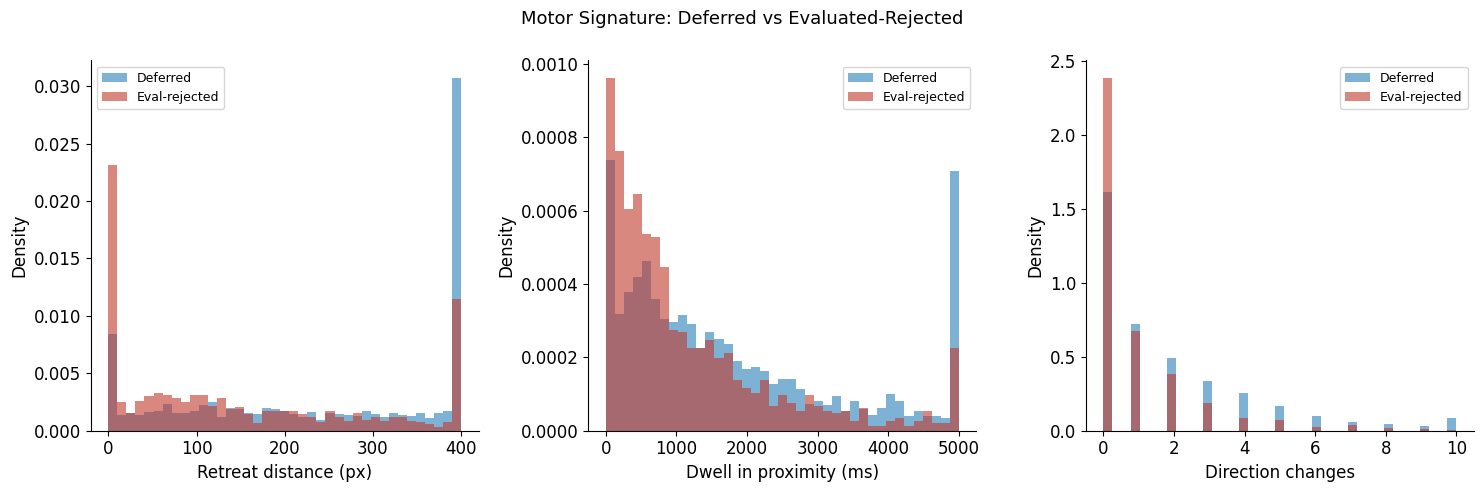

In [6]:
# Visualize the key separating metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_metrics = [
    ('retreat_dist', 'Retreat distance (px)', 400),
    ('dwell_in_proximity_ms', 'Dwell in proximity (ms)', 5000),
    ('direction_changes', 'Direction changes', 10),
]

for ax, (key, label, clip) in zip(axes, plot_metrics):
    d_vals = np.clip([raw[i][key] for i in range(n) if deferred_mask[i]], 0, clip)
    r_vals = np.clip([raw[i][key] for i in range(n) if rejected_mask[i]], 0, clip)
    bins = np.linspace(0, clip, 40)
    ax.hist(d_vals, bins=bins, alpha=0.6, density=True, label='Deferred', color='#2980b9')
    ax.hist(r_vals, bins=bins, alpha=0.6, density=True, label='Eval-rejected', color='#c0392b')
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

fig.suptitle('Motor Signature: Deferred vs Evaluated-Rejected', fontsize=13)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot22_deferred_vs_rejected_motor.png', dpi=150)
plt.show()

## 4. LOSO evaluation: 4-class and binary with regression feature

Two tests:
1. **Binary click prediction with regression added** — does regression improve AUC beyond M3/M4?
2. **4-class classification** — can the model separate all four classes?

In [7]:
# Feature arrays
FEATURES_M3 = ['position', 'total_dwell_ms',
               'min_dist', 'mean_dist', 'final_dist', 'retreat_dist',
               'dwell_in_proximity_ms', 'mean_approach_velocity',
               'max_approach_velocity', 'direction_changes', 'frac_decreasing']
FEATURES_M4 = ['min_dist', 'mean_dist', 'final_dist', 'retreat_dist',
               'dwell_in_proximity_ms', 'mean_approach_velocity',
               'max_approach_velocity', 'direction_changes', 'frac_decreasing']

def build_X(records, features):
    X = np.array([[r[f] for f in features] for r in records], dtype=np.float64)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

X_m3 = build_X(raw, FEATURES_M3)
X_m4 = build_X(raw, FEATURES_M4)

# Add regression as a feature
reg_col = regression_labels.astype(float).reshape(-1, 1)
X_m3r = np.hstack([X_m3, reg_col])  # M3 + regression
X_m4r = np.hstack([X_m4, reg_col])  # M4 + regression
X_reg_only = reg_col.copy()          # regression alone

y_click = clicked.astype(int)

le = LabelEncoder()
groups = le.fit_transform([r['participant'] for r in raw])

print(f'Feature matrices ready. M3: {X_m3.shape}, M3+reg: {X_m3r.shape}')

Feature matrices ready. M3: (19774, 11), M3+reg: (19774, 12)


In [8]:
def loso_binary(X, y, groups, name=''):
    """LOSO binary classification. Returns dict with AUC/AP arrays."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ])
    logo = LeaveOneGroupOut()
    auc_scores, ap_scores = [], []
    y_pred_all = np.full(len(y), np.nan)

    for train_ix, test_ix in logo.split(X, y, groups):
        pipe.fit(X[train_ix], y[train_ix])
        proba = pipe.predict_proba(X[test_ix])[:, 1]
        y_pred_all[test_ix] = proba
        if len(np.unique(y[test_ix])) == 2:
            auc_scores.append(roc_auc_score(y[test_ix], proba))
            ap_scores.append(average_precision_score(y[test_ix], proba))

    return {
        'name': name,
        'auc': np.array(auc_scores),
        'ap': np.array(ap_scores),
        'y_pred': y_pred_all,
    }

# Run binary click prediction: M3, M4, M3+reg, M4+reg
binary_results = {}
for name, X in [
    ('M3: Full', X_m3),
    ('M4: Approach only', X_m4),
    ('M3+reg: Full + regression', X_m3r),
    ('M4+reg: Approach + regression', X_m4r),
    ('Regression only', X_reg_only),
]:
    r = loso_binary(X, y_click, groups, name)
    binary_results[name] = r
    print(f'{name:35s} | AUC {r["auc"].mean():.3f}\u00b1{r["auc"].std():.3f} | AP {r["ap"].mean():.3f}')

print()
delta_m3 = binary_results['M3+reg: Full + regression']['auc'].mean() - binary_results['M3: Full']['auc'].mean()
delta_m4 = binary_results['M4+reg: Approach + regression']['auc'].mean() - binary_results['M4: Approach only']['auc'].mean()
print(f'Regression adds to M3: {delta_m3:+.3f} AUC')
print(f'Regression adds to M4: {delta_m4:+.3f} AUC')

M3: Full                            | AUC 0.871±0.040 | AP 0.598


M4: Approach only                   | AUC 0.873±0.039 | AP 0.597


M3+reg: Full + regression           | AUC 0.873±0.040 | AP 0.596


M4+reg: Approach + regression       | AUC 0.874±0.039 | AP 0.595
Regression only                     | AUC 0.566±0.066 | AP 0.165

Regression adds to M3: +0.001 AUC
Regression adds to M4: +0.002 AUC


## 5. Four-class LOSO classification

Multinomial logistic regression: clicked / deferred / evaluated-rejected / not-approached.
Compare to the 3-class result from notebook 21 (where approached-NC was one class).

In [9]:
def loso_multiclass(X, y_labels, groups, class_names, name=''):
    """LOSO multiclass classification. Returns per-class metrics."""
    le_mc = LabelEncoder()
    y_enc = le_mc.fit_transform(y_labels)
    n_classes = len(le_mc.classes_)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=1000, class_weight='balanced', solver='lbfgs'
        ))
    ])
    logo = LeaveOneGroupOut()
    y_pred_all = np.full(len(y_enc), -1, dtype=int)
    y_proba_all = np.full((len(y_enc), n_classes), np.nan)

    for train_ix, test_ix in logo.split(X, y_enc, groups):
        # Need all classes in training fold
        if len(np.unique(y_enc[train_ix])) < n_classes:
            continue
        pipe.fit(X[train_ix], y_enc[train_ix])
        y_pred_all[test_ix] = pipe.predict(X[test_ix])
        y_proba_all[test_ix] = pipe.predict_proba(X[test_ix])

    # Only evaluate records that got predictions
    valid = y_pred_all >= 0
    y_true_v = y_enc[valid]
    y_pred_v = y_pred_all[valid]

    report = classification_report(
        y_true_v, y_pred_v,
        target_names=le_mc.classes_,
        output_dict=True, zero_division=0
    )
    cm = confusion_matrix(y_true_v, y_pred_v)

    return {
        'name': name,
        'report': report,
        'cm': cm,
        'classes': le_mc.classes_,
        'y_true': y_enc,
        'y_pred': y_pred_all,
        'y_proba': y_proba_all,
        'valid': valid,
        'n_valid': valid.sum(),
    }

CLASS_NAMES_4 = ['clicked', 'deferred', 'evaluated_rejected', 'not_approached']
CLASS_NAMES_3 = ['clicked', 'approached_nc', 'not_approached']

# 3-class labels (for comparison with notebook 21)
labels_3 = np.full(n, '', dtype='U25')
labels_3[clicked] = 'clicked'
labels_3[~clicked & approached] = 'approached_nc'
labels_3[~clicked & ~approached] = 'not_approached'

# Run 4-class with M3+reg and M4+reg
mc_results = {}
for label, X, y_mc, classes in [
    ('3-class M3 (nb21 repro)', X_m3, labels_3, CLASS_NAMES_3),
    ('4-class M3+reg', X_m3r, labels_4, CLASS_NAMES_4),
    ('4-class M4+reg', X_m4r, labels_4, CLASS_NAMES_4),
]:
    r = loso_multiclass(X, y_mc, groups, classes, label)
    mc_results[label] = r
    wf1 = r['report']['weighted avg']['f1-score']
    print(f'{label:35s} | weighted F1 = {wf1:.3f} | N valid = {r["n_valid"]:,}')

3-class M3 (nb21 repro)             | weighted F1 = 0.810 | N valid = 19,774


4-class M3+reg                      | weighted F1 = 0.791 | N valid = 19,774


4-class M4+reg                      | weighted F1 = 0.789 | N valid = 19,774


In [10]:
# Detailed 4-class report (M3+reg)
r4 = mc_results['4-class M3+reg']

print('=== 4-Class Classification Report (M3+reg, LOSO) ===')
print()
print(f'{"Class":25s} {"Precision":>10s} {"Recall":>8s} {"F1":>8s} {"N":>8s}')
print('-' * 65)
for cls in CLASS_NAMES_4:
    rpt = r4['report'][cls]
    print(f'{cls:25s} {rpt["precision"]:10.3f} {rpt["recall"]:8.3f} {rpt["f1-score"]:8.3f} {rpt["support"]:8.0f}')
wgt = r4['report']['weighted avg']
print('-' * 65)
print(f'{"Weighted avg":25s} {wgt["precision"]:10.3f} {wgt["recall"]:8.3f} {wgt["f1-score"]:8.3f}')

print()
print('=== Confusion Matrix (rows=true, cols=predicted) ===')
print(f'{"":25s}', '  '.join(f'{c:>15s}' for c in r4['classes']))
for i, cls in enumerate(r4['classes']):
    row = r4['cm'][i]
    row_pct = row / row.sum() * 100
    cells = '  '.join(f'{v:>6d} ({p:4.1f}%)' for v, p in zip(row, row_pct))
    print(f'{cls:25s} {cells}')

=== 4-Class Classification Report (M3+reg, LOSO) ===

Class                      Precision   Recall       F1        N
-----------------------------------------------------------------
clicked                        0.376    0.462    0.415     2594
deferred                       0.588    0.870    0.702     2004
evaluated_rejected             0.541    0.939    0.686     1135
not_approached                 0.972    0.806    0.881    14041
-----------------------------------------------------------------
Weighted avg                   0.830    0.775    0.791

=== Confusion Matrix (rows=true, cols=predicted) ===
                                  clicked         deferred  evaluated_rejected   not_approached
clicked                     1199 (46.2%)     587 (22.6%)     480 (18.5%)     328 (12.6%)
deferred                     260 (13.0%)    1744 (87.0%)       0 ( 0.0%)       0 ( 0.0%)
evaluated_rejected            69 ( 6.1%)       0 ( 0.0%)    1066 (93.9%)       0 ( 0.0%)
not_approached        

In [11]:
# Compare 3-class vs 4-class: did splitting help?
r3 = mc_results['3-class M3 (nb21 repro)']

print('=== 3-class vs 4-class Comparison ===')
print()
print('3-class (notebook 21 reproduction):')
for cls in CLASS_NAMES_3:
    f1 = r3['report'][cls]['f1-score']
    rec = r3['report'][cls]['recall']
    print(f'  {cls:25s}  F1={f1:.3f}  recall={rec:.3f}')
print(f'  Weighted F1: {r3["report"]["weighted avg"]["f1-score"]:.3f}')

print()
print('4-class (M3+reg):')
for cls in CLASS_NAMES_4:
    f1 = r4['report'][cls]['f1-score']
    rec = r4['report'][cls]['recall']
    print(f'  {cls:25s}  F1={f1:.3f}  recall={rec:.3f}')
print(f'  Weighted F1: {r4["report"]["weighted avg"]["f1-score"]:.3f}')

print()
print('Key question: is deferred separable from evaluated-rejected?')
if 'deferred' in r4['report'] and 'evaluated_rejected' in r4['report']:
    d_f1 = r4['report']['deferred']['f1-score']
    e_f1 = r4['report']['evaluated_rejected']['f1-score']
    print(f'  Deferred F1:           {d_f1:.3f}')
    print(f'  Evaluated-rejected F1: {e_f1:.3f}')
    print(f'  If both > 0.3 with decent recall, the split is empirically justified.')

=== 3-class vs 4-class Comparison ===

3-class (notebook 21 reproduction):
  clicked                    F1=0.461  recall=0.590
  approached_nc              F1=0.722  recall=0.790
  not_approached             F1=0.895  recall=0.829
  Weighted F1: 0.810

4-class (M3+reg):
  clicked                    F1=0.415  recall=0.462
  deferred                   F1=0.702  recall=0.870
  evaluated_rejected         F1=0.686  recall=0.939
  not_approached             F1=0.881  recall=0.806
  Weighted F1: 0.791

Key question: is deferred separable from evaluated-rejected?
  Deferred F1:           0.702
  Evaluated-rejected F1: 0.686
  If both > 0.3 with decent recall, the split is empirically justified.


## 6. Confusion matrix visualization

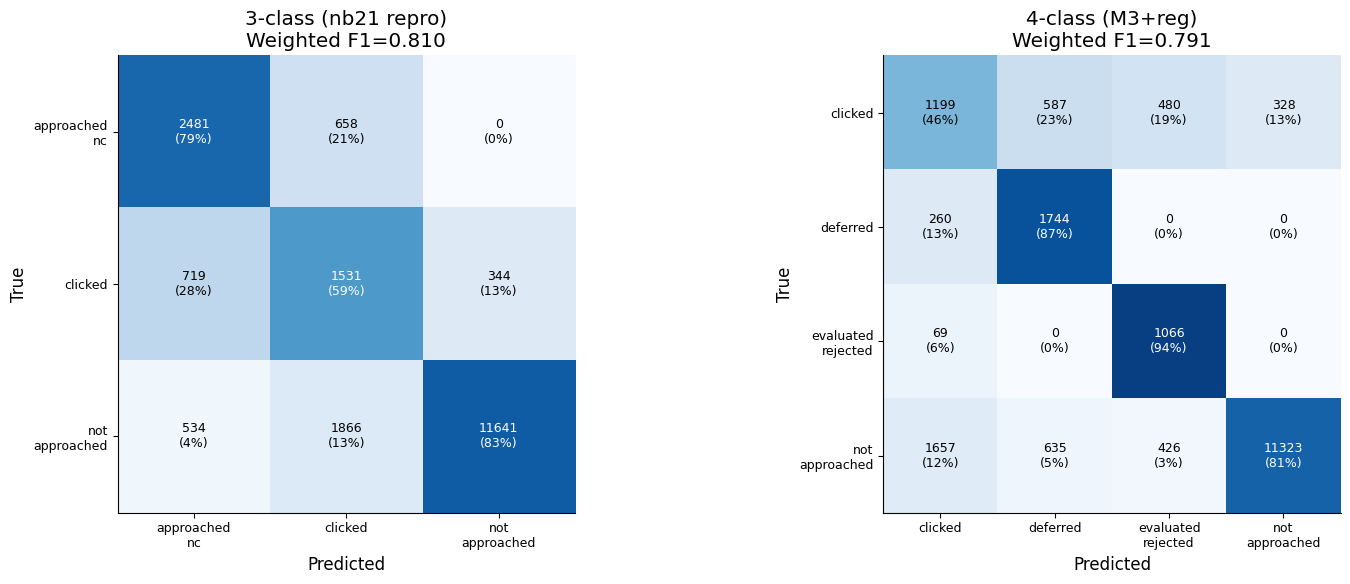

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, result, title in [
    (ax1, r3, '3-class (nb21 repro)'),
    (ax2, r4, '4-class (M3+reg)'),
]:
    cm = result['cm']
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    classes = result['classes']
    n_cls = len(classes)

    im = ax.imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    for i in range(n_cls):
        for j in range(n_cls):
            color = 'white' if cm_pct[i, j] > 50 else 'black'
            ax.text(j, i, f'{cm[i,j]:d}\n({cm_pct[i,j]:.0f}%)',
                    ha='center', va='center', fontsize=9, color=color)
    ax.set_xticks(range(n_cls))
    ax.set_xticklabels([c.replace('_', '\n') for c in classes], fontsize=9)
    ax.set_yticks(range(n_cls))
    ax.set_yticklabels([c.replace('_', '\n') for c in classes], fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    wf1 = result['report']['weighted avg']['f1-score']
    ax.set_title(f'{title}\nWeighted F1={wf1:.3f}')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'plot22_confusion_3v4.png', dpi=150)
plt.show()

## 7. Click rate by predicted class

The ultimate validation: if the 4-class taxonomy is meaningful, the deferred class
should have a higher click rate than evaluated-rejected when we look at the
actual outcomes for results the model assigns to each class.

In [13]:
# Use M3+reg OOF predictions to assign classes
r4m = mc_results['4-class M3+reg']
valid = r4m['valid']
y_pred_labels = np.full(n, '', dtype='U25')
for i in range(n):
    if valid[i] and r4m['y_pred'][i] >= 0:
        y_pred_labels[i] = r4m['classes'][r4m['y_pred'][i]]

print('=== Click Rate by PREDICTED Class (OOF) ===')
print(f'{"Predicted class":25s} {"N":>8s} {"Clicked":>8s} {"Click rate":>10s}')
print('-' * 55)
for cls in CLASS_NAMES_4:
    mask = y_pred_labels == cls
    if mask.sum() == 0:
        continue
    n_cls = mask.sum()
    n_click = clicked[mask].sum()
    rate = n_click / n_cls * 100
    print(f'{cls:25s} {n_cls:8d} {n_click:8d} {rate:9.1f}%')

print()
print('If deferred click rate > evaluated-rejected click rate, the split is validated.')

=== Click Rate by PREDICTED Class (OOF) ===
Predicted class                  N  Clicked Click rate
-------------------------------------------------------
clicked                       3185     1199      37.6%
deferred                      2966      587      19.8%
evaluated_rejected            1972      480      24.3%
not_approached               11651      328       2.8%

If deferred click rate > evaluated-rejected click rate, the split is validated.


## 9. Summary for model-analysis.md

## 8. Element-type interaction terms

Notebook 20 shows top ads have 2× approach rate, 50px more retreat, and 2.3× longer dwell
than organic results. The model so far treats all results equally. Adding interaction terms
(e.g. `retreat_dist × is_top_ad`) tests whether element-type calibration improves prediction.

Connects to Leif's C/W/L framework: if evaluation cost differs by element type,
the model should know what kind of element the cursor is approaching.

In [14]:
# Load typed features (same records, adds etype column)
TYPED_PATH = Path('../AdSERP/data/cursor-approach-features-typed.json')
with open(TYPED_PATH) as f:
    raw_typed = json.load(f)

# Verify alignment
assert len(raw_typed) == n
for i in range(n):
    assert raw_typed[i]['trial_id'] == raw[i]['trial_id']
    assert raw_typed[i]['position'] == raw[i]['position']

etypes = np.array([r['etype'] for r in raw_typed])
print('Element types:', Counter(etypes))

# One-hot encode element type
is_top_ad = (etypes == 'dd_top').astype(float)
is_native_ad = (etypes == 'native_ad').astype(float)
# organic is the reference category (dropped)

print(f'Top ads: {is_top_ad.sum():.0f} ({is_top_ad.mean()*100:.1f}%)')
print(f'Native ads: {is_native_ad.sum():.0f} ({is_native_ad.mean()*100:.1f}%)')
print(f'Organic: {(etypes == "organic").sum()} ({(etypes == "organic").mean()*100:.1f}%)')

Element types: Counter({np.str_('organic'): 12712, np.str_('native_ad'): 3660, np.str_('dd_top'): 1581, np.str_('image_pack'): 846, np.str_('knowledge_panel'): 398, np.str_('paa'): 357, np.str_('unknown_widget'): 141, np.str_('top_places'): 48, np.str_('other_widget'): 31})
Top ads: 1581 (8.0%)
Native ads: 3660 (18.5%)
Organic: 12712 (64.3%)


In [15]:
# Build interaction features
# Key approach metrics × element type indicators
retreat = np.array([r['retreat_dist'] for r in raw], dtype=float)
dwell_prox = np.array([r['dwell_in_proximity_ms'] for r in raw], dtype=float)
dir_chg = np.array([r['direction_changes'] for r in raw], dtype=float)
min_d = np.array([r['min_dist'] for r in raw], dtype=float)

for arr in [retreat, dwell_prox, dir_chg, min_d]:
    arr[~np.isfinite(arr)] = 0.0

# Main effects: element type dummies
etype_main = np.column_stack([is_top_ad, is_native_ad])

# Interaction terms: approach metrics × is_top_ad
# (top ads are the interesting case — 2× approach rate, discrimination cost)
interactions_top = np.column_stack([
    retreat * is_top_ad,
    dwell_prox * is_top_ad,
    dir_chg * is_top_ad,
    min_d * is_top_ad,
])

# Interaction terms: approach metrics × is_native_ad
interactions_native = np.column_stack([
    retreat * is_native_ad,
    dwell_prox * is_native_ad,
    dir_chg * is_native_ad,
    min_d * is_native_ad,
])

# Model tiers for element-type test
# M3e: M3 + element type main effects
X_m3e = np.hstack([X_m3, etype_main])
# M3ei: M3 + element type + interactions
X_m3ei = np.hstack([X_m3, etype_main, interactions_top, interactions_native])
# M4e: M4 + element type main effects
X_m4e = np.hstack([X_m4, etype_main])
# M4ei: M4 + element type + interactions
X_m4ei = np.hstack([X_m4, etype_main, interactions_top, interactions_native])

INTERACTION_NAMES = [
    'retreat×top_ad', 'dwell_prox×top_ad', 'dir_chg×top_ad', 'min_dist×top_ad',
    'retreat×native_ad', 'dwell_prox×native_ad', 'dir_chg×native_ad', 'min_dist×native_ad',
]

print(f'M3:   {X_m3.shape[1]} features')
print(f'M3e:  {X_m3e.shape[1]} features (+2 element type dummies)')
print(f'M3ei: {X_m3ei.shape[1]} features (+2 dummies +8 interactions)')
print(f'M4ei: {X_m4ei.shape[1]} features')

M3:   11 features
M3e:  13 features (+2 element type dummies)
M3ei: 21 features (+2 dummies +8 interactions)
M4ei: 19 features


In [16]:
# LOSO binary click prediction: element-type models
print('=== Binary Click Prediction: Element-Type Models ===')
print(f'{"Model":40s} | {"AUC":>14s} | {"AP":>8s} | {"Δ AUC vs M3":>12s}')
print('-' * 82)

m3_auc = binary_results['M3: Full']['auc'].mean()

etype_binary = {}
for name, X in [
    ('M3: Full (baseline)', X_m3),
    ('M3e: + element type', X_m3e),
    ('M3ei: + element type + interactions', X_m3ei),
    ('M4: Approach only (baseline)', X_m4),
    ('M4e: + element type', X_m4e),
    ('M4ei: + element type + interactions', X_m4ei),
]:
    r = loso_binary(X, y_click, groups, name)
    etype_binary[name] = r
    delta = r['auc'].mean() - m3_auc
    print(f'{name:40s} | {r["auc"].mean():.3f}±{r["auc"].std():.3f} | {r["ap"].mean():.3f} | {delta:+.4f}')

print()
print('Key question: do interaction terms improve over main effects alone?')
m3e_auc = etype_binary['M3e: + element type']['auc'].mean()
m3ei_auc = etype_binary['M3ei: + element type + interactions']['auc'].mean()
print(f'  M3e  → M3ei: {m3ei_auc - m3e_auc:+.4f} AUC')
m4e_auc = etype_binary['M4e: + element type']['auc'].mean()
m4ei_auc = etype_binary['M4ei: + element type + interactions']['auc'].mean()
print(f'  M4e  → M4ei: {m4ei_auc - m4e_auc:+.4f} AUC')

=== Binary Click Prediction: Element-Type Models ===
Model                                    |            AUC |       AP |  Δ AUC vs M3
----------------------------------------------------------------------------------


M3: Full (baseline)                      | 0.871±0.040 | 0.598 | +0.0000


M3e: + element type                      | 0.879±0.042 | 0.613 | +0.0071


M3ei: + element type + interactions      | 0.882±0.041 | 0.618 | +0.0100


M4: Approach only (baseline)             | 0.873±0.039 | 0.597 | +0.0011


M4e: + element type                      | 0.879±0.041 | 0.608 | +0.0079


M4ei: + element type + interactions      | 0.883±0.039 | 0.615 | +0.0111

Key question: do interaction terms improve over main effects alone?
  M3e  → M3ei: +0.0030 AUC
  M4e  → M4ei: +0.0032 AUC


In [17]:
# Interaction term coefficients: what does the model learn about element types?
# Fit M3ei on full data for coefficient inspection (descriptive, not inferential)
pipe_ei = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
pipe_ei.fit(X_m3ei, y_click)
coefs = pipe_ei.named_steps['clf'].coef_[0]

# Feature names for M3ei
feat_names_ei = FEATURES_M3 + ['is_top_ad', 'is_native_ad'] + INTERACTION_NAMES

print('=== M3ei Feature Coefficients (full-data refit) ===')
print(f'{"Feature":30s} {"Coef":>8s} {"Direction":>12s}')
print('-' * 55)

# Sort by absolute value, show all
order = np.argsort(np.abs(coefs))[::-1]
for idx in order:
    name = feat_names_ei[idx]
    c = coefs[idx]
    direction = '→ click' if c > 0 else '→ skip'
    marker = ' ***' if '×' in name or 'is_' in name else ''
    print(f'{name:30s} {c:+8.3f} {direction:>12s}{marker}')

=== M3ei Feature Coefficients (full-data refit) ===
Feature                            Coef    Direction
-------------------------------------------------------
dwell_in_proximity_ms            +1.082      → click
final_dist                       -0.862       → skip
min_dist×top_ad                  -0.831       → skip ***
min_dist                         -0.760       → skip
mean_dist                        +0.583      → click
dwell_prox×top_ad                -0.447       → skip ***
is_top_ad                        +0.401      → click ***
is_native_ad                     -0.318       → skip ***
retreat×top_ad                   -0.315       → skip ***
max_approach_velocity            +0.272      → click
retreat_dist                     -0.222       → skip
position                         -0.169       → skip
dwell_prox×native_ad             -0.122       → skip ***
mean_approach_velocity           +0.050      → click
min_dist×native_ad               +0.047      → click ***
frac_decreasing 

In [18]:
# Per-element-type AUC: does the model perform differently on ads vs organic?
# Split evaluation by element type using M3 OOF predictions
m3_pred = binary_results['M3: Full']['y_pred']
m3ei_pred = etype_binary['M3ei: + element type + interactions']['y_pred']

print('=== Per-Element-Type AUC (OOF predictions) ===')
print(f'{"Element":15s} {"N":>6s} {"Click%":>7s} | {"M3 AUC":>8s} {"M3ei AUC":>9s} {"Δ":>7s}')
print('-' * 60)

for etype_name in ['organic', 'dd_top', 'native_ad']:
    mask = (etypes == etype_name) & np.isfinite(m3_pred) & np.isfinite(m3ei_pred)
    y_sub = y_click[mask]
    if len(np.unique(y_sub)) < 2:
        print(f'{etype_name:15s} {mask.sum():6d} — insufficient class diversity')
        continue
    auc_m3 = roc_auc_score(y_sub, m3_pred[mask])
    auc_m3ei = roc_auc_score(y_sub, m3ei_pred[mask])
    cr = y_sub.mean() * 100
    delta = auc_m3ei - auc_m3
    print(f'{etype_name:15s} {mask.sum():6d} {cr:6.1f}% | {auc_m3:8.3f} {auc_m3ei:9.3f} {delta:+7.3f}')

print()
print('If Δ > 0 for top ads, interactions help where they should — the discrimination cost element.')

=== Per-Element-Type AUC (OOF predictions) ===
Element              N  Click% |   M3 AUC  M3ei AUC       Δ
------------------------------------------------------------
organic          12712   15.9% |    0.867     0.869  +0.002
dd_top            1581   17.1% |    0.916     0.932  +0.015
native_ad         3660    5.1% |    0.834     0.822  -0.013

If Δ > 0 for top ads, interactions help where they should — the discrimination cost element.


In [19]:
print('=' * 70)
print('SUMMARY FOR MODEL-ANALYSIS.MD')
print('=' * 70)
print()

# Binary results
print('--- Binary Click Prediction (LOSO AUC) ---')
for name, r in binary_results.items():
    print(f'  {name:35s}: {r["auc"].mean():.3f} \u00b1 {r["auc"].std():.3f}')

print()
print('--- 4-Class Taxonomy (LOSO, M3+reg) ---')
for cls in CLASS_NAMES_4:
    rpt = r4['report'][cls]
    print(f'  {cls:25s}: P={rpt["precision"]:.3f}  R={rpt["recall"]:.3f}  F1={rpt["f1-score"]:.3f}  N={rpt["support"]:.0f}')

print()
print('--- Class Counts ---')
for cls in CLASS_NAMES_4:
    c = counts_4[cls]
    print(f'  {cls:25s}: {c:6,} ({c/n*100:.1f}%)')

print()
print('=' * 70)

SUMMARY FOR MODEL-ANALYSIS.MD

--- Binary Click Prediction (LOSO AUC) ---
  M3: Full                           : 0.871 ± 0.040
  M4: Approach only                  : 0.873 ± 0.039
  M3+reg: Full + regression          : 0.873 ± 0.040
  M4+reg: Approach + regression      : 0.874 ± 0.039
  Regression only                    : 0.566 ± 0.066

--- 4-Class Taxonomy (LOSO, M3+reg) ---
  clicked                  : P=0.376  R=0.462  F1=0.415  N=2594
  deferred                 : P=0.588  R=0.870  F1=0.702  N=2004
  evaluated_rejected       : P=0.541  R=0.939  F1=0.686  N=1135
  not_approached           : P=0.972  R=0.806  F1=0.881  N=14041

--- Class Counts ---
  clicked                  :  2,594 (13.1%)
  deferred                 :  2,004 (10.1%)
  evaluated_rejected       :  1,135 (5.7%)
  not_approached           : 14,041 (71.0%)

